In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd

In [21]:
driver_species_20 = pd.read_csv('driver_species_20.csv')

In [143]:
driver_species_20['mean_relative_abundance'].max()

0.0002827424831532421

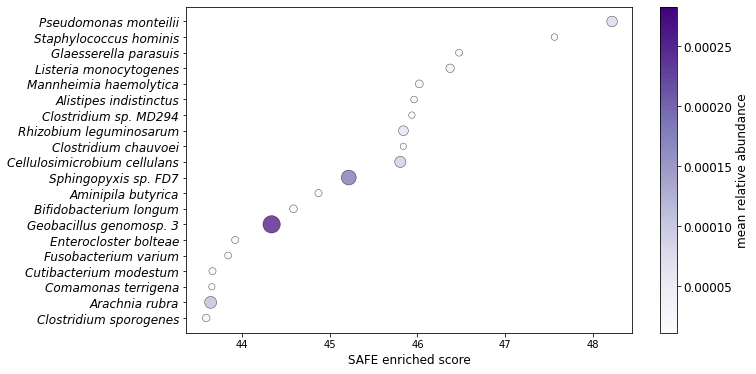

In [144]:

df_small = driver_species_20

plt.figure(figsize=(10, 6))

norm = mcolors.Normalize(vmin=driver_species_20['mean_relative_abundance'].min(), 
                         vmax=driver_species_20['mean_relative_abundance'].max())

scatter = sns.scatterplot(
    data=df_small,
    y=df_small.index,  # Microbes on y-axis
    x="SAFE enriched score",  # Score on x-axis
    size="mean_relative_abundance",  # Dot size based on mean abundance
    sizes=(40, 300),  # Adjust dot size range
    alpha=0.7,
    hue="mean_relative_abundance",  # Color the dots by abundance (optional)
    palette="Purples",  # Optional: change palette
    edgecolor="black",  # Circle borders are black
    linewidth=0.5,  # Set the thickness of the border
    legend=None,  # Disable automatic legend
)

sm = plt.cm.ScalarMappable(cmap="Purples", norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label("mean relative abundance", size=12)
cbar.ax.tick_params(labelsize=12)

plt.xticks()  
plt.xlabel("SAFE enriched score", size=12)
plt.ylabel("")
plt.gca().tick_params(axis='y', labelsize=12) 
plt.gca().yaxis.set_tick_params(labelrotation=0)
for label in plt.gca().get_yticklabels():
    label.set_fontstyle('italic')
plt.savefig('Driver_species_MG_control_0407_sputum_new_clr.pdf', bbox_inches='tight')

In [132]:
edges_df_with_relative_abundance = pd.read_csv('edges_df_with_RL_15SC_MG_HostT.csv', sep = '\t')

In [133]:
filtered_df = edges_df_with_relative_abundance[edges_df_with_relative_abundance['start'].isin(driver_species_20.index)]

In [137]:
edges_df_with_relative_abundance

,start,end,weight,mean_relative_abundance
0,Abiotrophia defectiva,NPNT,11.066792,2.731085e-04
1,Abiotrophia defectiva,MYC,7.355055,2.731085e-04
2,Abyssibius alkaniclasticus,CHIA,10.923674,2.077267e-06
3,Acidihalobacter ferrooxydans,FAM13A,11.796667,3.170970e-06
4,Acidovorax carolinensis,MFAP2,9.094738,4.116410e-05
5,Acidovorax sp. 1608163,MAP2K1,7.282447,9.967560e-06
6,Acinetobacter bereziniae,RET,15.659270,6.340402e-07
7,Acinetobacter bereziniae,IL10,9.160603,6.340402e-07
8,Acinetobacter colistiniresistens,RET,20.381238,1.953870e-07
9,Acinetobacter colistiniresistens,CHIA,5.957813,1.953870e-07


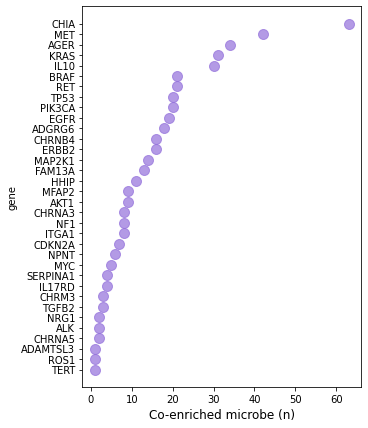

In [138]:
import matplotlib.pyplot as plt

df = edges_df_with_relative_abundance
value_counts = df.iloc[:, 1].value_counts()

sorted_counts = value_counts.sort_values(ascending=True)

plt.figure(figsize=(5, 7))
plt.scatter(sorted_counts.values, sorted_counts.index, color="mediumpurple", s=100, alpha=0.7)
plt.xlabel("Co-enriched microbe (n)", size=12)
plt.ylabel("gene")
plt.title("")
plt.xticks()
plt.grid(axis="y", linestyle="", alpha=0.6)
plt.savefig('MG_coenriched_microbe_n_forgenes_15SC_sputum_clr.pdf',bbox_inches='tight')